# Fermi-Hubbard 模型神经网络量子态求解

本案例使用 NetKet 框架，通过神经网络（RBM 和 FNN）求解一维 Fermi-Hubbard 模型的基态能量。

## 模型介绍

Fermi-Hubbard 模型是描述强关联电子系统的经典模型，其哈密顿量为：

$$H = -t \sum_{\langle i,j \rangle, \sigma} (c_{i\sigma}^\dagger c_{j\sigma} + c_{j\sigma}^\dagger c_{i\sigma}) + U \sum_i n_{i\uparrow} n_{i\downarrow}$$

其中：
- $t$ 是跳跃参数（hopping parameter）
- $U$ 是库仑相互作用参数
- $c_{i\sigma}^\dagger$ 和 $c_{i\sigma}$ 分别是产生和湮灭算符
- $n_{i\sigma} = c_{i\sigma}^\dagger c_{i\sigma}$ 是粒子数算符

## 1. 导入必要的库

In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from flax import nnx
import jax.numpy as jnp
import jax

print(f"NetKet version: {nk.__version__}")

NetKet version: 3.18


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 定义系统参数

设置一维晶格、跳跃参数和库仑相互作用参数。

In [2]:
L = 4
D = 1
t = 1.0
U = 0.1

print(f"系统参数:")
print(f"  晶格长度 L = {L}")
print(f"  空间维度 D = {D}")
print(f"  跳跃参数 t = {t}")
print(f"  库仑相互作用 U = {U}")

系统参数:
  晶格长度 L = 4
  空间维度 D = 1
  跳跃参数 t = 1.0
  库仑相互作用 U = 0.1


## 3. 构建晶格和希尔伯特空间

晶格信息:
  格点数: 4
  希尔伯特空间维度: 36


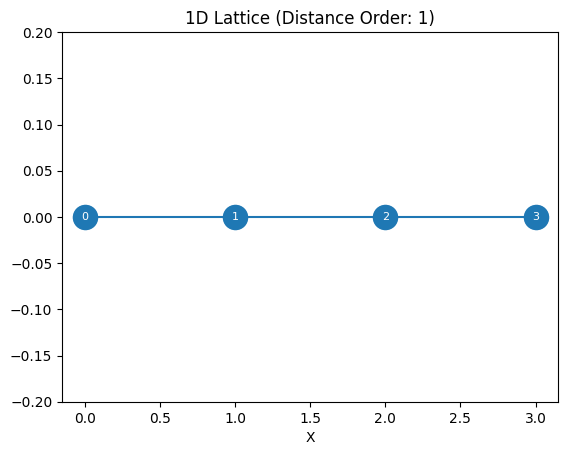

<Axes: title={'center': '1D Lattice (Distance Order: 1)'}, xlabel='X'>

In [3]:
g = nk.graph.Hypercube(length=L, n_dim=D, pbc=False)
n_sites = g.n_nodes

hilber_space = nk.hilbert.SpinOrbitalFermions(n_sites, s=1/2, n_fermions_per_spin=(2, 2))

print(f"晶格信息:")
print(f"  格点数: {n_sites}")
print(f"  希尔伯特空间维度: {hilber_space.n_states}")

g.draw()

## 4. 构建 Fermi-Hubbard 哈密顿量

In [4]:
def c(site, sz):
    return nk.operator.fermion.destroy(hilber_space, site, sz=sz)

def cdag(site, sz):
    return nk.operator.fermion.create(hilber_space, site, sz=sz)

def nc(site, sz):
    return nk.operator.fermion.number(hilber_space, site, sz=sz)

up = +1
down = -1
ham = 0.0

for sz in (up, down):
    for u, v in g.edges():
        ham += -t * cdag(u, sz) * c(v, sz) - t * cdag(v, sz) * c(u, sz)

for u in g.nodes():
    ham += U * nc(u, up) * nc(u, down)

print("Fermi-Hubbard 哈密顿量:")
print(ham.operator_string())

Fermi-Hubbard 哈密顿量:
-1.0 [4^ 5] +
-1.0 [5^ 4] +
-1.0 [5^ 6] +
-1.0 [6^ 5] +
-1.0 [6^ 7] +
-1.0 [7^ 6] +
-1.0 [0^ 1] +
-1.0 [1^ 0] +
-1.0 [1^ 2] +
-1.0 [2^ 1] +
-1.0 [2^ 3] +
-1.0 [3^ 2] +
0.1 [4^ 4 0^ 0] +
0.1 [5^ 5 1^ 1] +
0.1 [6^ 6 2^ 2] +
0.1 [7^ 7 3^ 3]


## 5. 计算精确基态能量（作为参考）

In [7]:
ed_result = nk.exact.lanczos_ed(ham, k=3)
exact_energy = ed_result[0]

print(f"精确基态能量: {exact_energy:.6f}")

ed_energies = np.linalg.eigvalsh(ham.to_dense())
print(f"\n前5个能级:")
for i, e in enumerate(ed_energies[:5]):
    print(f"  E{i} = {e:.6f}")

精确基态能量: -4.373176

前5个能级:
  E0 = -4.373176
  E1 = -3.166638
  E2 = -3.106628
  E3 = -2.176787
  E4 = -2.138920


## 6. 配置采样器和优化器

In [10]:
sampler = nk.sampler.MetropolisFermionHop(
    hilber_space, 
    graph=g, 
    n_chains=16, 
    sweep_size=64
)

opt = nk.optimizer.Sgd(learning_rate=0.01)
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=False)

print(f"采样器配置:")
print(f"  链数: {sampler.n_chains}")
print(f"  扫描大小: {sampler.sweep_size}")
print(f"\n优化器配置:")
print(f"  SR 对角偏移: {sr.diag_shift}")

采样器配置:
  链数: 16
  扫描大小: 64

优化器配置:
  SR 对角偏移: 0.1


## 7. 方法一：使用 RBM（受限玻尔兹曼机）

In [11]:
model_rbm = nk.models.RBM(
    alpha=1, 
    param_dtype=complex, 
    use_visible_bias=False
)

vstate_rbm = nk.vqs.MCState(
    sampler, 
    model_rbm, 
    n_discard_per_chain=10, 
    n_samples=512
)

print(f"RBM 模型参数数量: {vstate_rbm.n_parameters}")

RBM 模型参数数量: 72


In [12]:
gs_rbm = nk.driver.VMC(
    ham, 
    opt, 
    variational_state=vstate_rbm, 
    preconditioner=sr
)

exp_name_rbm = "fermions_RBM"
gs_rbm.run(500, out=exp_name_rbm)

print(f"\nRBM 训练完成")

100%|██████████| 500/500 [00:18<00:00, 26.74it/s, Energy=-4.3713-0.0000j ± 0.0032 [σ²=0.0052, R̂=1.0096]]


RBM 训练完成


## 8. 方法二：使用 FNN（前馈神经网络）

In [13]:
class FFN(nnx.Module):
    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)

model_fnn = FFN(N=L*2, alpha=1, rngs=nnx.Rngs(42))
vstate_fnn = nk.vqs.MCState(sampler, model_fnn, n_samples=1008)

print(f"FNN 模型参数数量: {vstate_fnn.n_parameters}")

FNN 模型参数数量: 72


In [14]:
gs_fnn = nk.driver.VMC(
    ham, 
    opt, 
    variational_state=vstate_fnn, 
    preconditioner=sr
)

exp_name_fnn = "fermions_FNN"
gs_fnn.run(500, out=exp_name_fnn)

print(f"\nFNN 训练完成")

100%|██████████| 500/500 [00:09<00:00, 52.40it/s, Energy=-4.3727 ± 0.0021 [σ²=0.0045, R̂=1.0048]]



FNN 训练完成


## 9. 结果分析与可视化

TypeError: unhashable type: 'dict'

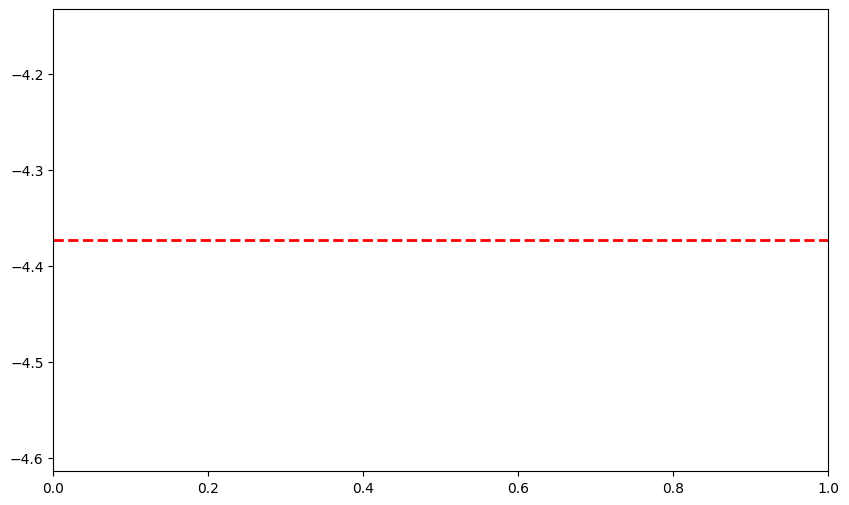

In [15]:
with open(f'./{exp_name_rbm}.log') as f:
    data_rbm = json.load(f)

with open(f'./{exp_name_fnn}.log') as f:
    data_fnn = json.load(f)

x_rbm = data_rbm["Energy"]["iters"]
y_rbm = data_rbm["Energy"]["Mean"]
x_fnn = data_fnn["Energy"]["iters"]
y_fnn = data_fnn["Energy"]["Mean"]

plt.figure(figsize=(10, 6))
plt.axhline(exact_energy, color="red", linestyle="--", linewidth=2, label=f"精确基态能量: {exact_energy:.6f}")
plt.plot(x_rbm, y_rbm, color="blue", linewidth=2, label="VMC RBM")
plt.plot(x_fnn, y_fnn, color="green", linewidth=2, label="VMC FNN")
plt.xlabel("迭代步数", fontsize=12)
plt.ylabel("能量", fontsize=12)
plt.title("Fermi-Hubbard 模型基态能量收敛曲线", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 结果对比

In [ ]:
final_energy_rbm = y_rbm[-1]
final_energy_fnn = y_fnn[-1]

error_rbm = abs(final_energy_rbm - exact_energy)
error_fnn = abs(final_energy_fnn - exact_energy)

print("="*60)
print("结果对比")
print("="*60)
print(f"精确基态能量:           {exact_energy:.8f}")
print(f"RBM 最终能量:            {final_energy_rbm:.8f}")
print(f"RBM 绝对误差:            {error_rbm:.8f}")
print(f"RBM 相对误差:            {error_rbm/abs(exact_energy)*100:.4f}%")
print()
print(f"FNN 最终能量:            {final_energy_fnn:.8f}")
print(f"FNN 绝对误差:            {error_fnn:.8f}")
print(f"FNN 相对误差:            {error_fnn/abs(exact_energy)*100:.4f}%")
print("="*60)

## 11. 总结

本案例展示了如何使用 NetKet 框架通过神经网络求解 Fermi-Hubbard 模型的基态能量。

### 主要步骤：
1. 定义系统参数（晶格大小、跳跃参数、库仑相互作用）
2. 构建晶格和希尔伯特空间
3. 构建 Fermi-Hubbard 哈密顿量
4. 计算精确基态能量作为参考
5. 配置采样器和优化器
6. 使用 RBM 模型进行变分蒙特卡洛优化
7. 使用 FNN 模型进行变分蒙特卡洛优化
8. 对比两种方法的结果

### 关键点：
- RBM 和 FNN 都能很好地逼近基态能量
- 随机重配置（SR）预条件器显著加速收敛
- 费米子采样器需要特殊处理以保持反对称性